Wrong way error rate: 2.00%
Right way error rate: 50.00%


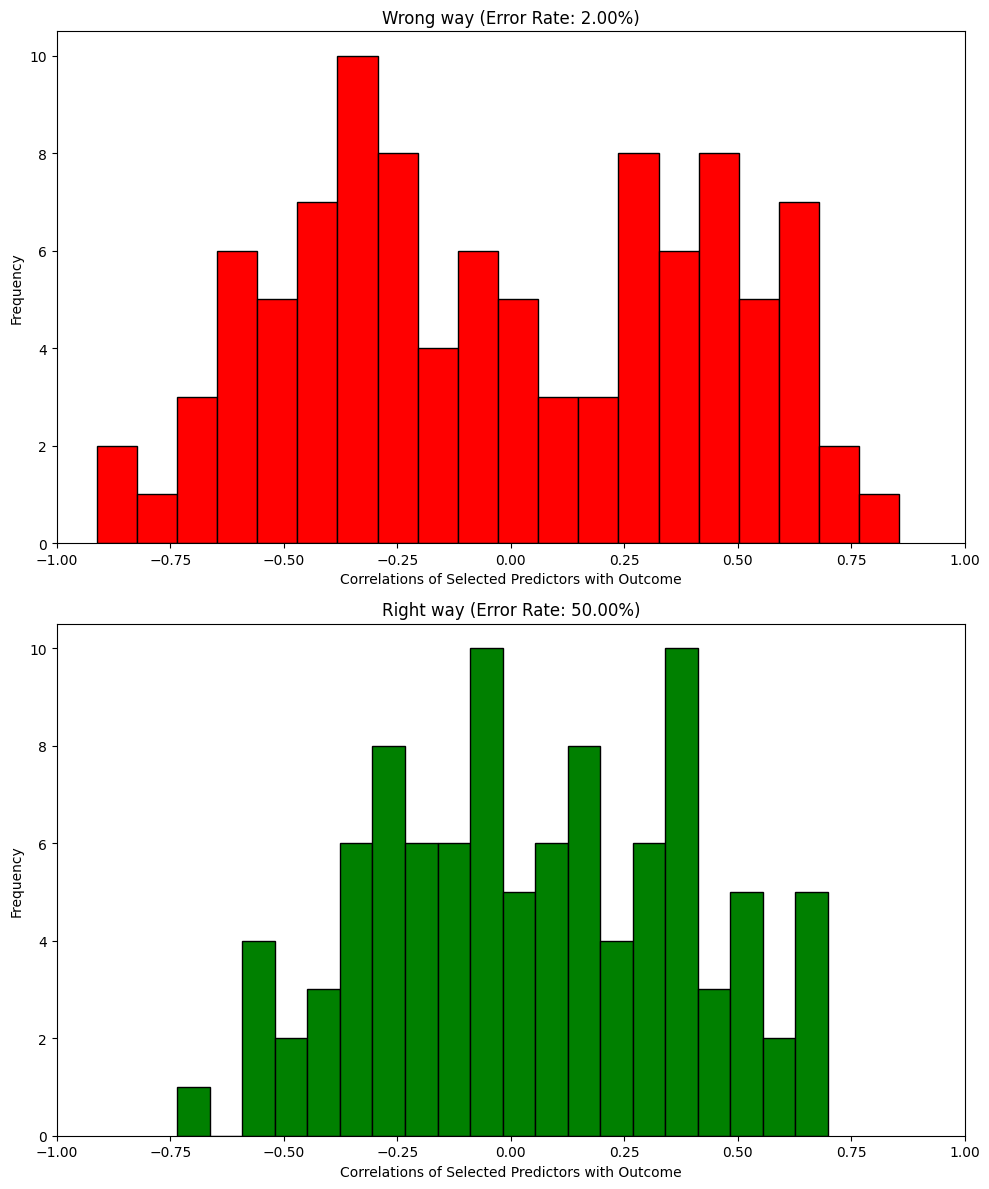

In [63]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import KFold
import numpy as np
import matplotlib.pyplot as plt

def generateData(n_samples=50, n_predictors=5000):
    X = np.random.randn(n_samples, n_predictors)
    y = np.concatenate([np.zeros(n_samples // 2), np.ones(n_samples // 2)])
    return X, y

def wrong_way(X, y, n_predictors=100, n_test=10):

    selector = SelectKBest(f_classif, k=n_predictors)
    X_selected = selector.fit_transform(X, y)
    selected_features = selector.get_support(indices=True)
    kf = KFold(n_splits=5, shuffle=True)
    scores = []
    
    for train_idx, test_idx in kf.split(X_selected):
        X_train, X_test = X_selected[train_idx], X_selected[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        knn = KNeighborsClassifier(n_neighbors=1)
        knn.fit(X_train, y_train)
        score = knn.score(X_test, y_test)
        scores.append(score)
    
    error_rate = 1 - np.mean(scores)
    
    test_indices = np.random.choice(X.shape[0], n_test, replace=False)
    correlations = [np.corrcoef(X[test_indices, idx], y[test_indices])[0, 1] 
                   for idx in selected_features]
    
    return error_rate, correlations

def right_way(X, y, n_predictors=100, n_test=10):

    test_indices = np.random.choice(X.shape[0], n_test, replace=False)
    train_indices = np.setdiff1d(np.arange(X.shape[0]), test_indices)
    
    X_train_corr = X[train_indices]
    y_train_corr = y[train_indices]
    X_test_corr = X[test_indices]
    y_test_corr = y[test_indices]
    
    selector_corr = SelectKBest(f_classif, k=n_predictors)
    selector_corr.fit(X_train_corr, y_train_corr)
    selected_features = selector_corr.get_support(indices=True)
    
    correlations = [np.corrcoef(X_test_corr[:, idx], y_test_corr)[0, 1] 
                   for idx in selected_features]
    
    kf = KFold(n_splits=5, shuffle=True)
    scores = []
    
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        selector = SelectKBest(f_classif, k=n_predictors)
        X_train_selected = selector.fit_transform(X_train, y_train)
        X_test_selected = selector.transform(X_test)
        
        knn = KNeighborsClassifier(n_neighbors=1)
        knn.fit(X_train_selected, y_train)
        score = knn.score(X_test_selected, y_test)
        scores.append(score)
    
    error_rate = 1 - np.mean(scores)
    
    return error_rate, correlations

def main():
    # Generate data
    X, y = generateData()
    
    # Calculate error rates and correlations
    wrong_error, wrong_correlations = wrong_way(X, y)
    right_error, right_correlations = right_way(X, y)
    
    print(f"Wrong way error rate: {wrong_error:.2%}")
    print(f"Right way error rate: {right_error:.2%}")
    
    # Create plots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))
    
    # Wrong way histogram
    ax1.hist(wrong_correlations, bins=20, color='red', edgecolor='black')
    ax1.set_title(f"Wrong way (Error Rate: {wrong_error:.2%})")
    ax1.set_xlabel("Correlations of Selected Predictors with Outcome")
    ax1.set_ylabel("Frequency")
    ax1.set_xlim(-1, 1)
    
    # Right way histogram
    ax2.hist(right_correlations, bins=20, color='green', edgecolor='black')
    ax2.set_title(f"Right way (Error Rate: {right_error:.2%})")
    ax2.set_xlabel("Correlations of Selected Predictors with Outcome")
    ax2.set_ylabel("Frequency")
    ax2.set_xlim(-1, 1)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()